### Supervised Learning - Image Recognition with Support Vector Machines

In [1]:
import IPython
import sklearn as sk
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print ('IPython version:', IPython.__version__)
print ('numpy version:', np.__version__)
print ('scikit-learn version:', sk.__version__)
print ('matplotlib version:', matplotlib.__version__)

IPython version: 9.7.0
numpy version: 2.3.5
scikit-learn version: 1.7.2
matplotlib version: 3.10.6


##### Import the olivetti faces dataset

In [2]:
from sklearn.datasets import fetch_olivetti_faces
#fetch the faces data
faces = fetch_olivetti_faces()
print(faces.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [3]:
print(faces.keys())

dict_keys(['data', 'images', 'target', 'DESCR'])


In [4]:
print(faces.images.shape)

(400, 64, 64)


In [5]:
print(faces.target.shape)

(400,)


In [6]:
print(np.max(faces.data))
print(np.min(faces.data))
print(np.mean(faces.data))

1.0
0.0
0.5470425


#### Plot The First 20 images.

In [12]:
def print_faces(images, target, top_n):
    #set up the figure size in inches
    fig = plt.figure(figsize=(12,12))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
    for i in range(min(top_n, len(images))):
        #plot the images in a matrix of 20x20
        p = fig.add_subplot(20, 20, i+1, xticks=[], yticks=[])
        p.imshow(images[i], cmap=plt.cm.bone)

        #label the image with target value
        p.text(0, 14, str(target[i]))
        p.text(0, 60, str(i))
    plt.show()
        

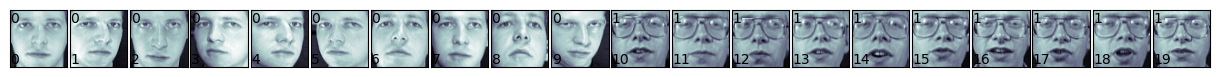

In [13]:
print_faces(faces.images, faces.target, 20)

###### Plot all the faces in a matrix of 20x20, for each one, we'll put it target value in the top left corner and it index in the bottom left corner. It may take a few seconds.

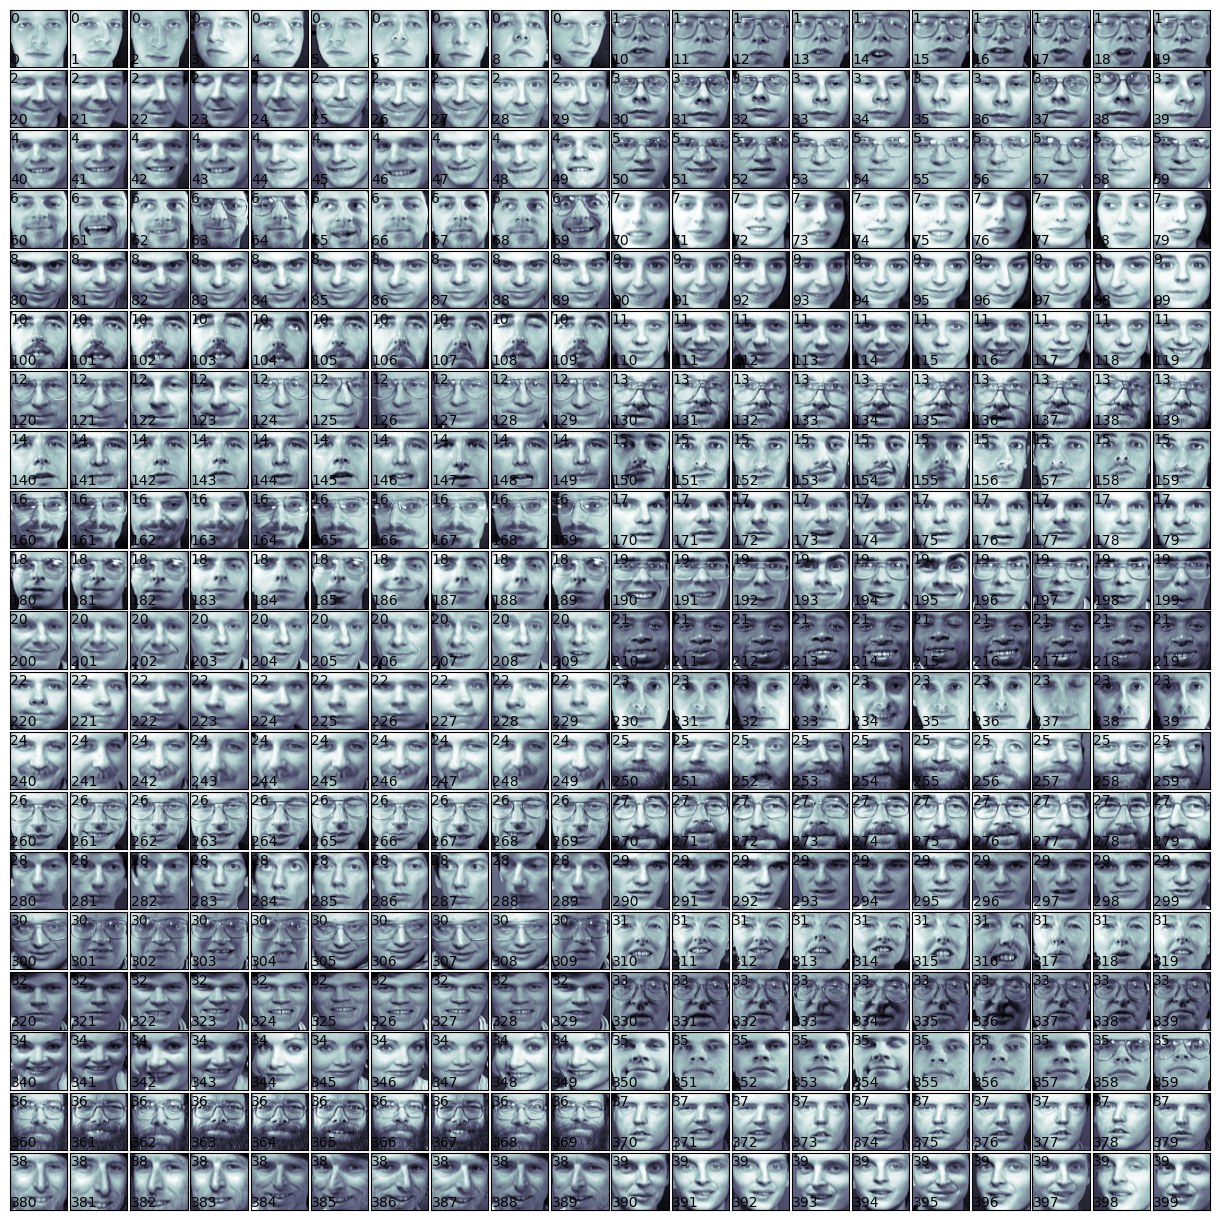

In [14]:
print_faces(faces.images, faces.target, 400)

###### We will try to build a classifier whose model is a hyperplane that separates instances (points) of one class from the rest.

In [15]:
#import the SVC class from the sklearn.svm module
from sklearn.svm import SVC
svc_1 = SVC(kernel="linear")
print(svc_1)

SVC(kernel='linear')


##### Build Training and Testing sets

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    faces.data, faces.target, test_size=0.25, random_state=0)

##### perform 5-fold cross-validation

In [25]:
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import sem

def evaluate_cross_validation(clf, x, y, K):
    # Create a k-fold cross validation iterator using n_splits
    cv = KFold(n_splits=K, shuffle=True, random_state=0)
    #by default the score used is the one returned by score method of the estimator(accuracy)
    scores = cross_val_score(clf, x, y, cv=cv)
    print(scores)
    print("mean score: {0:.3f} (+/-{1:.3f})".format(
        np.mean(scores), sem(scores)))

In [26]:
evaluate_cross_validation(svc_1, faces.data, faces.target, K=5)

[0.9875 0.975  0.9875 0.95   0.975 ]
mean score: 0.975 (+/-0.007)


In [28]:
from sklearn import metrics

def train_and_evaluate(clf, x_train, x_test, y_train, y_test):
    clf.fit(x_train, y_train)

    print("Accuracy on Training set:")
    print(clf.score(x_train, y_train))
    print("Accuracy on Testing set:")
    print(clf.score(x_test, y_test))

    y_pred = clf.predict(x_test)

    print("Classification Report:")
    print(metrics.classification_report(y_test, y_pred))
    print("Confusion matrix:")
    print(metrics.confusion_matrix(y_test, y_pred))
    

##### Let's measure precision and recall on the evaluation set, for each class.

In [29]:
train_and_evaluate(svc_1, x_train, x_test, y_train, y_test)

Accuracy on Training set:
1.0
Accuracy on Testing set:
0.99
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         4
           7       1.00      0.67      0.80         3
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00         3
          17       1.00      1.00      1.00         

###### h3. Discriminate people with or without glasses
###### Performace on face recognition very. Now, another problem: let's try to classify images of people with and without glasses. By hand, we have marked people with glasses.

In [30]:
# the index range of images of people with glases
glasses = [
	(10, 19), (30, 32), (37, 38), (50, 59), (63, 64),
	(69, 69), (120, 121), (124, 129), (130, 139), (160, 161),
	(164, 169), (180, 182), (185, 185), (189, 189), (190, 192),
	(194, 194), (196, 199), (260, 269), (270, 279), (300, 309),
	(330, 339), (358, 359), (360, 369)
]

#### Creating training and tests sets for the new problem

In [31]:
def create_target(segments):
    #create a new y array of target size initialized with zeros
    y = np.zeros(faces.target.shape[0])
    #put 1 in the specified segments
    for (start, end) in segments:
        y[start:end + 1] = 1
    return y

In [32]:
target_glasses = create_target(glasses)

x_train, x_test, y_train, y_test = train_test_split(
    faces.data, target_glasses, test_size=0.25,random_state=0)

##### with a Linear kernel

In [33]:
svc_2 = SVC(kernel ="linear")
evaluate_cross_validation(svc_2, x_train, y_train, 5)
train_and_evaluate(svc_2, x_train, x_test, y_train, y_test)

[1.         0.95       0.98333333 0.98333333 0.93333333]
mean score: 0.970 (+/-0.012)
Accuracy on Training set:
1.0
Accuracy on Testing set:
0.99
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99        67
         1.0       0.97      1.00      0.99        33

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Confusion matrix:
[[66  1]
 [ 0 33]]


###### Almost perfect! Now, let's separate 10 completely different images (all from the same person, sometimes with glasses and sometimes without glasses). With this we'll try to discard that it's remembering faces, instead of features related with glasses.We'll separate the subject with indexes from 30 to 39. We'll train and evaluate in the rest of the 390 instances. After that, we'll evaluate again over the separated 10 instances.

In [34]:
x_test = faces.data[30:40]
y_test = target_glasses[30:40]

print(y_test.shape[0])

select = np.ones(target_glasses.shape[0])
select[30:40] = 0
x_train = faces.data[select == 1]
y_train = target_glasses[select == 1]

print(y_train.shape[0])

10
390


In [35]:
svc_3 = SVC(kernel="linear")
train_and_evaluate(svc_3, x_train, x_test, y_train, y_test)
y_pred = svc_3.predict(x_test)


Accuracy on Training set:
1.0
Accuracy on Testing set:
0.9
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91         5
         1.0       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10

Confusion matrix:
[[5 0]
 [1 4]]


###### Show our evaluation faces, and their predicted category. Face number eight is incorrectly classified as no-glasses (probably because his eyes are closed!).

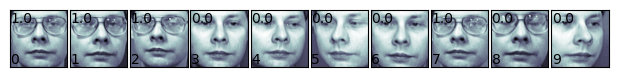

In [36]:
eval_faces = [np.reshape(a, (64,64)) for a in x_test]
print_faces(eval_faces, y_pred, 10)

#### Prepared by Peter Owili